In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib
# For higher resoltion figures
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

In [2]:
# Loading the results form the two-state training 
two_state_data = pd.read_csv("../../results/results_two_state_test_leakyrelu.csv")
two_state_data = two_state_data.drop_duplicates()
two_state_data

,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,spearman_abund_val,...,pearson_act_test,pearson_abund_val,pearson_act_val,pearson_abund_train,pearson_act_train,K1_negative,K2_negative,abund_negative,relu,total_params
0,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,1,Hill,0.1,0.5,1,0.519428,0.779136,0.574596,...,0.789157,0.571437,0.777340,0.587565,0.789084,True,NaN,True,False,202
1,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,2,Hill,0.1,0.5,1,0.519428,0.776834,0.574596,...,0.787751,0.571437,0.791198,0.587565,0.782325,True,NaN,True,False,221
2,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,3,Hill,0.1,0.5,1,0.519428,0.786043,0.574596,...,0.803522,0.571437,0.810199,0.587565,0.806435,True,NaN,True,False,240
3,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,4,Hill,0.1,0.5,1,0.519428,0.784657,0.574596,...,0.789791,0.571437,0.783153,0.587565,0.792003,True,NaN,True,False,259
4,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,5,Hill,0.1,0.5,1,0.519428,0.778433,0.574596,...,0.787330,0.571437,0.808630,0.587565,0.807478,True,NaN,True,False,278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2881,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,20,Linear,0.5,0.1,1,0.560198,0.732493,0.597843,...,0.655939,0.597979,0.641656,0.664441,0.622397,True,NaN,False,False,1228
2882,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,25,Linear,0.5,0.1,1,0.562032,0.782053,0.598293,...,0.792979,0.597790,0.775981,0.664348,0.832191,True,NaN,False,False,1323
2883,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,30,Linear,0.5,0.1,1,0.560385,0.775470,0.597661,...,0.756525,0.593982,0.770693,0.665019,0.791388,True,NaN,False,False,1418
2884,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,35,Linear,0.5,0.1,1,0.559565,0.754051,0.606087,...,0.673927,0.602055,0.656244,0.664805,0.644075,True,NaN,False,False,1513


In [3]:
# Loading the results form the three-state training 
three_state_data = pd.read_csv("../../results/results_three_state_abund_test_leakyrelu.csv")
three_state_data

,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,spearman_abund_val,...,pearson_act_test,pearson_abund_val,pearson_act_val,pearson_abund_train,pearson_act_train,K1_negative,K2_negative,abund_negative,relu,total_params
0,../../model_data/three_state_abundmodel_b10_e2...,three_state_abund,5,Hill,0.1,0.5,1,0.519428,0.774539,0.574596,...,0.825351,0.571437,0.839248,0.587565,0.853031,True,True,True,False,416
1,../../model_data/three_state_abundmodel_b10_e2...,three_state_abund,10,Hill,0.1,0.5,1,0.519428,0.785024,0.574596,...,0.820393,0.571437,0.850732,0.587565,0.857697,True,True,True,False,606
2,../../model_data/three_state_abundmodel_b10_e2...,three_state_abund,15,Hill,0.1,0.5,1,0.519428,0.796339,0.574596,...,0.824940,0.571437,0.843628,0.587565,0.864411,True,True,True,False,796
3,../../model_data/three_state_abundmodel_b10_e2...,three_state_abund,20,Hill,0.1,0.5,1,0.519428,0.785431,0.574596,...,0.838126,0.571437,0.811553,0.587565,0.882825,True,True,True,False,986
4,../../model_data/three_state_abundmodel_b10_e2...,three_state_abund,30,Hill,0.1,0.5,1,0.519428,0.766184,0.574596,...,0.797427,0.571437,0.809321,0.587565,0.811249,False,True,True,False,1366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1074,../../model_data/three_state_abundmodel_b10_e2...,three_state_abund,10,Hill,0.5,0.1,1,0.564631,0.774933,0.593873,...,0.779375,0.592485,0.793390,0.664159,0.834423,True,True,False,False,1271
1075,../../model_data/three_state_abundmodel_b10_e2...,three_state_abund,15,Hill,0.5,0.1,1,0.564631,0.780313,0.593873,...,0.810155,0.592485,0.796683,0.664159,0.853553,True,True,False,False,1461
1076,../../model_data/three_state_abundmodel_b10_e2...,three_state_abund,20,Hill,0.5,0.1,1,0.564631,0.777267,0.593873,...,0.798970,0.592485,0.810126,0.664159,0.837300,False,False,False,False,1651
1077,../../model_data/three_state_abundmodel_b10_e2...,three_state_abund,30,Hill,0.5,0.1,1,0.564631,0.762863,0.593873,...,0.772395,0.592485,0.784833,0.664159,0.798082,False,True,False,False,2031


In [4]:
# Loading the results form the simple abund training 
simple_abund_data = pd.read_csv("../../results/results_simple_abund_test_LeakyReLU.csv")
simple_abund_data

,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,spearman_abund_val,...,pearson_act_test,pearson_abund_val,pearson_act_val,pearson_abund_train,pearson_act_train,K1_negative,K2_negative,abund_negative,relu,total_params
0,../../model_data/simple_abundmodel_b10_e200_L0...,simple_abund,5,NaN,NaN,0.1,NaN,0.513356,NaN,0.574815,...,NaN,0.571805,NaN,0.579233,NaN,NaN,NaN,NaN,NaN,138
1,../../model_data/simple_abundmodel_b10_e200_L0...,simple_abund,10,NaN,NaN,0.1,NaN,0.550505,NaN,0.586531,...,NaN,0.581606,NaN,0.603344,NaN,NaN,NaN,NaN,NaN,233
2,../../model_data/simple_abundmodel_b10_e200_L0...,simple_abund,15,NaN,NaN,0.1,NaN,0.564765,NaN,0.597314,...,NaN,0.599065,NaN,0.622986,NaN,NaN,NaN,NaN,NaN,328
3,../../model_data/simple_abundmodel_b10_e200_L0...,simple_abund,20,NaN,NaN,0.1,NaN,0.567057,NaN,0.585515,...,NaN,0.592384,NaN,0.629630,NaN,NaN,NaN,NaN,NaN,423
4,../../model_data/simple_abundmodel_b10_e200_L0...,simple_abund,30,NaN,NaN,0.1,NaN,0.571828,NaN,0.597317,...,NaN,0.597605,NaN,0.640647,NaN,NaN,NaN,NaN,NaN,613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,../../model_data/simple_abundmodel_b10_e200_L0...,simple_abund,10,NaN,NaN,0.1,NaN,0.547721,NaN,0.595003,...,NaN,0.587670,NaN,0.612962,NaN,NaN,NaN,NaN,NaN,233
176,../../model_data/simple_abundmodel_b10_e200_L0...,simple_abund,15,NaN,NaN,0.1,NaN,0.547346,NaN,0.586681,...,NaN,0.586729,NaN,0.612056,NaN,NaN,NaN,NaN,NaN,328
177,../../model_data/simple_abundmodel_b10_e200_L0...,simple_abund,20,NaN,NaN,0.1,NaN,0.568762,NaN,0.588308,...,NaN,0.589240,NaN,0.630223,NaN,NaN,NaN,NaN,NaN,423
178,../../model_data/simple_abundmodel_b10_e200_L0...,simple_abund,30,NaN,NaN,0.1,NaN,0.534657,NaN,0.593882,...,NaN,0.590598,NaN,0.623698,NaN,NaN,NaN,NaN,NaN,613


In [5]:
# Loading the results form the simple act training 
simple_act_data = pd.read_csv("../../results/results_simple_act_test_LeakyReLU.csv")
simple_act_data

,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,spearman_abund_val,...,pearson_act_test,pearson_abund_val,pearson_act_val,pearson_abund_train,pearson_act_train,K1_negative,K2_negative,abund_negative,relu,total_params
0,../../model_data/simple_actmodel_b10_e200_L0.0...,simple_act,5,NaN,NaN,0.5,NaN,NaN,0.785880,NaN,...,0.837335,NaN,0.855690,NaN,0.839007,NaN,NaN,NaN,NaN,138
1,../../model_data/simple_actmodel_b10_e200_L0.0...,simple_act,10,NaN,NaN,0.5,NaN,NaN,0.792886,NaN,...,0.853520,NaN,0.861056,NaN,0.847421,NaN,NaN,NaN,NaN,233
2,../../model_data/simple_actmodel_b10_e200_L0.0...,simple_act,15,NaN,NaN,0.5,NaN,NaN,0.783407,NaN,...,0.833765,NaN,0.864919,NaN,0.834071,NaN,NaN,NaN,NaN,328
3,../../model_data/simple_actmodel_b10_e200_L0.0...,simple_act,20,NaN,NaN,0.5,NaN,NaN,0.782586,NaN,...,0.848406,NaN,0.855642,NaN,0.870468,NaN,NaN,NaN,NaN,423
4,../../model_data/simple_actmodel_b10_e200_L0.0...,simple_act,30,NaN,NaN,0.5,NaN,NaN,0.782716,NaN,...,0.845804,NaN,0.864660,NaN,0.866519,NaN,NaN,NaN,NaN,613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,../../model_data/simple_actmodel_b10_e200_L0.0...,simple_act,10,NaN,NaN,0.5,NaN,NaN,0.794091,NaN,...,0.842676,NaN,0.867877,NaN,0.853467,NaN,NaN,NaN,NaN,233
176,../../model_data/simple_actmodel_b10_e200_L0.0...,simple_act,15,NaN,NaN,0.5,NaN,NaN,0.792182,NaN,...,0.855601,NaN,0.849178,NaN,0.858254,NaN,NaN,NaN,NaN,328
177,../../model_data/simple_actmodel_b10_e200_L0.0...,simple_act,20,NaN,NaN,0.5,NaN,NaN,0.786433,NaN,...,0.848818,NaN,0.847019,NaN,0.856887,NaN,NaN,NaN,NaN,423
178,../../model_data/simple_actmodel_b10_e200_L0.0...,simple_act,30,NaN,NaN,0.5,NaN,NaN,0.782802,NaN,...,0.835565,NaN,0.844137,NaN,0.846053,NaN,NaN,NaN,NaN,613


/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_32964/1077661400.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend(frameon=False)
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


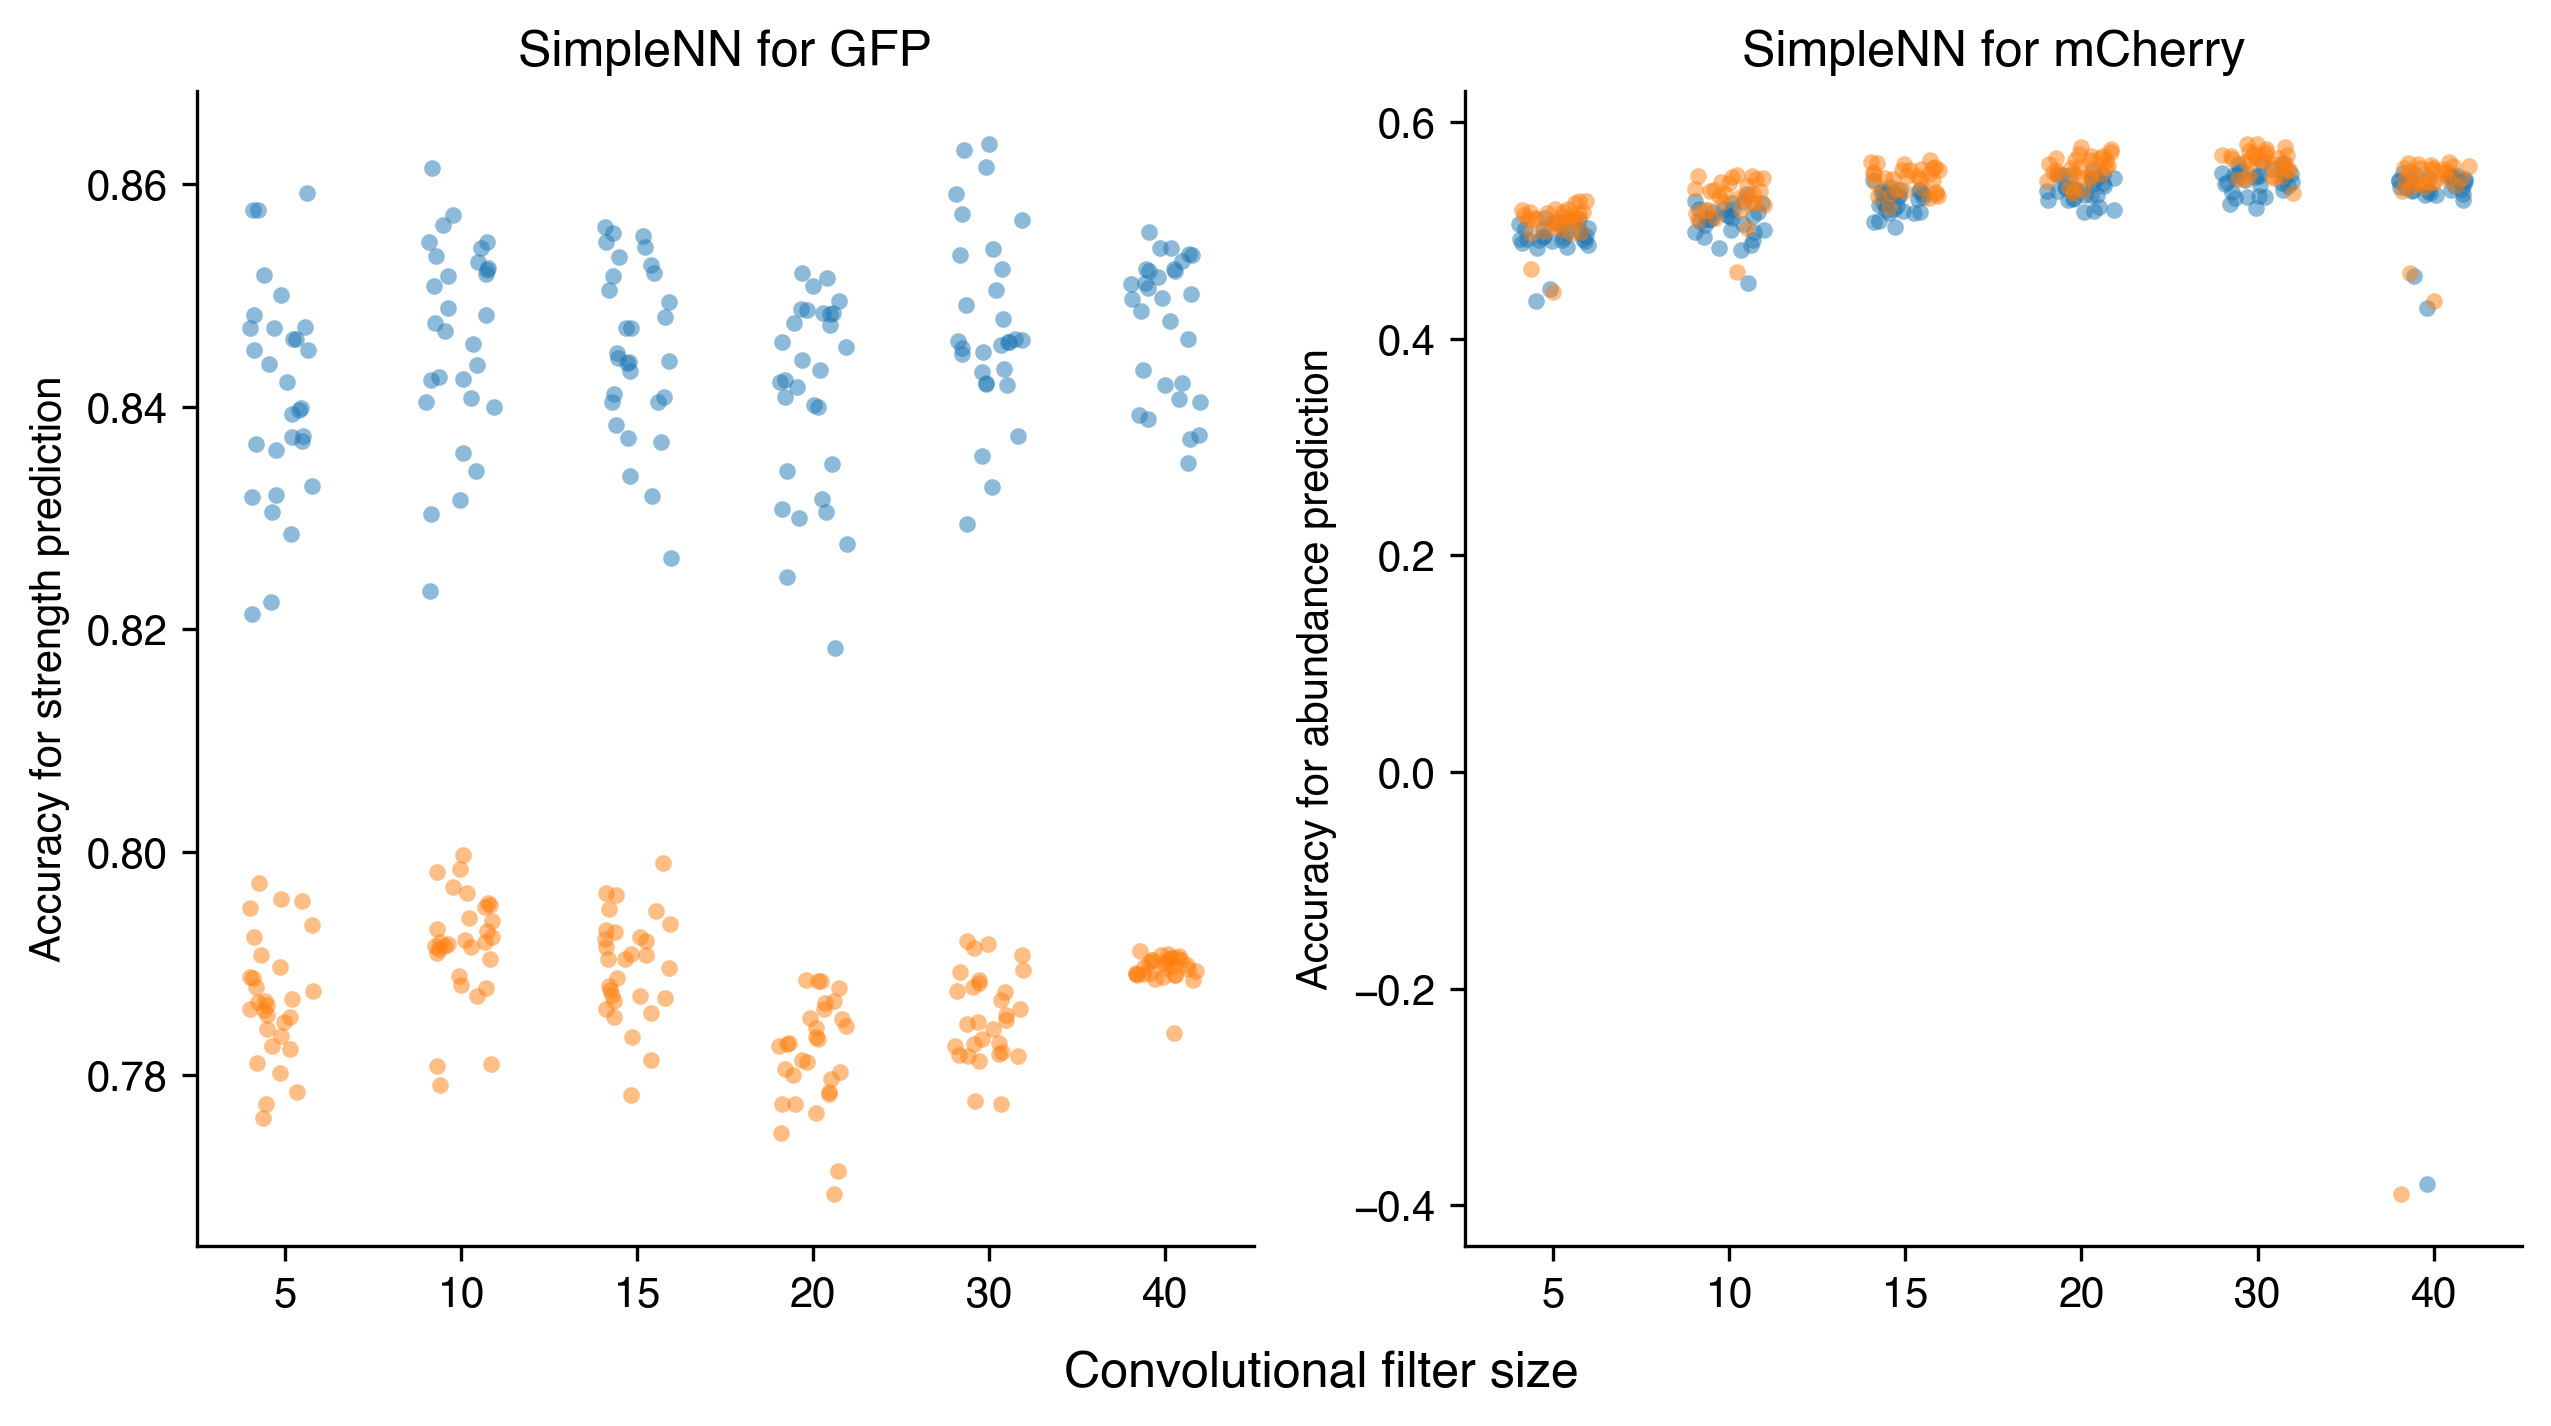

In [13]:
# Reading in the data from all the NN trainings
fig, axs = plt.subplots(1,2, figsize = (10,5))

sns.stripplot(x="kernel_size", y="pearson_act_test", data=simple_act_data, jitter=0.2, size=4, alpha=0.5, ax=axs[0])
sns.stripplot(x="kernel_size", y="spearman_act_test", data=simple_act_data, jitter=0.2, size=4, alpha=0.5, ax=axs[0])

sns.stripplot(x="kernel_size", y="pearson_abund_test", data=simple_abund_data, jitter=0.2, size=4, alpha=0.5, ax=axs[1])
sns.stripplot(x="kernel_size", y="spearman_abund_test", data=simple_abund_data, jitter=0.2, size=4, alpha=0.5, ax=axs[1])

axs[1].set_xlabel("")
axs[0].set_xlabel("")
axs[0].set_ylabel("")
axs[1].set_ylabel("")

fig.supxlabel("Convolutional filter size")
axs[0].set_ylabel("Accuracy for strength prediction")
axs[1].set_ylabel("Accuracy for abundance prediction")


sns.despine()

axs[0].legend(frameon=False)



axs[0].set_title("SimpleNN for GFP")
axs[1].set_title("SimpleNN for mCherry")

plt.savefig("../../figures/for_revision/simple_seed_variation.pdf", format='pdf', bbox_inches='tight')
plt.savefig("../../figures/for_revision/simple_seed_variation.png", format='png', bbox_inches='tight')

In [14]:
three_state_data.drop_duplicates()

,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,spearman_abund_val,...,pearson_act_test,pearson_abund_val,pearson_act_val,pearson_abund_train,pearson_act_train,K1_negative,K2_negative,abund_negative,relu,total_params
0,../../model_data/three_state_abundmodel_b10_e2...,three_state_abund,5,Hill,0.1,0.5,1,0.519428,0.774539,0.574596,...,0.825351,0.571437,0.839248,0.587565,0.853031,True,True,True,False,416
1,../../model_data/three_state_abundmodel_b10_e2...,three_state_abund,10,Hill,0.1,0.5,1,0.519428,0.785024,0.574596,...,0.820393,0.571437,0.850732,0.587565,0.857697,True,True,True,False,606
2,../../model_data/three_state_abundmodel_b10_e2...,three_state_abund,15,Hill,0.1,0.5,1,0.519428,0.796339,0.574596,...,0.824940,0.571437,0.843628,0.587565,0.864411,True,True,True,False,796
3,../../model_data/three_state_abundmodel_b10_e2...,three_state_abund,20,Hill,0.1,0.5,1,0.519428,0.785431,0.574596,...,0.838126,0.571437,0.811553,0.587565,0.882825,True,True,True,False,986
4,../../model_data/three_state_abundmodel_b10_e2...,three_state_abund,30,Hill,0.1,0.5,1,0.519428,0.766184,0.574596,...,0.797427,0.571437,0.809321,0.587565,0.811249,False,True,True,False,1366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354,../../model_data/three_state_abundmodel_b10_e2...,three_state_abund,10,Hill,0.1,0.5,1,0.564631,0.780592,0.593873,...,0.799611,0.592485,0.810306,0.664159,0.841997,True,True,False,False,1271
355,../../model_data/three_state_abundmodel_b10_e2...,three_state_abund,15,Hill,0.1,0.5,1,0.564631,0.784604,0.593873,...,0.809338,0.592485,0.802131,0.664159,0.848937,True,True,False,False,1461
356,../../model_data/three_state_abundmodel_b10_e2...,three_state_abund,20,Hill,0.1,0.5,1,0.564631,0.779276,0.593873,...,0.802214,0.592485,0.807845,0.664159,0.833734,False,False,False,False,1651
357,../../model_data/three_state_abundmodel_b10_e2...,three_state_abund,30,Hill,0.1,0.5,1,0.564631,0.779791,0.593873,...,0.822153,0.592485,0.808115,0.664159,0.878460,False,True,False,False,2031


,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,spearman_abund_val,...,pearson_act_test,pearson_abund_val,pearson_act_val,pearson_abund_train,pearson_act_train,K1_negative,K2_negative,abund_negative,relu,total_params
1446,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,1,Hill,0.5,0.1,2,0.519428,0.757172,0.574596,...,0.740394,0.571437,0.685221,0.587565,0.747938,True,NaN,True,False,202
1447,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,2,Hill,0.5,0.1,2,0.519428,0.760353,0.574596,...,0.741711,0.571437,0.734408,0.587565,0.755368,True,NaN,True,False,221
1448,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,3,Hill,0.5,0.1,2,0.519428,0.749991,0.574596,...,0.719903,0.571437,0.748832,0.587565,0.749769,True,NaN,True,False,240
1449,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,4,Hill,0.5,0.1,2,0.519428,0.752485,0.574596,...,0.728847,0.571437,0.738238,0.587565,0.767157,True,NaN,True,False,259
1450,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,5,Hill,0.5,0.1,2,0.519428,0.732394,0.574596,...,0.703158,0.571437,0.697831,0.587565,0.765500,True,NaN,True,False,278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2161,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,20,Hill,0.5,0.1,2,0.564631,0.732140,0.593873,...,0.695573,0.592485,0.681714,0.664159,0.746189,False,NaN,False,False,1228
2162,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,25,Hill,0.5,0.1,2,0.564631,0.753578,0.593873,...,0.722201,0.592485,0.680141,0.664159,0.767571,False,NaN,False,False,1323
2163,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,30,Hill,0.5,0.1,2,0.564631,0.745898,0.593873,...,0.735044,0.592485,0.746436,0.664159,0.797833,False,NaN,False,False,1418
2164,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,35,Hill,0.5,0.1,2,0.564631,0.745800,0.593873,...,0.746674,0.592485,0.776518,0.664159,0.816295,False,NaN,False,False,1513


In [51]:
simple_act_data.sort_values("pearson_act_test", ascending=False)['pearson_act_test']

64     0.863655
40     0.863027
34     0.861582
67     0.861483
102    0.859231
         ...   
45     0.824723
61     0.823456
126    0.822481
6      0.821422
75     0.818312
Name: pearson_act_test, Length: 180, dtype: float64

(array([1., 3., 3., 2., 1., 1., 2., 6., 6., 5.]),
 array([0.83493465, 0.83701191, 0.83908916, 0.84116642, 0.84324367,
        0.84532092, 0.84739818, 0.84947543, 0.85155269, 0.85362994,
        0.85570719]),
 <BarContainer object of 10 artists>)

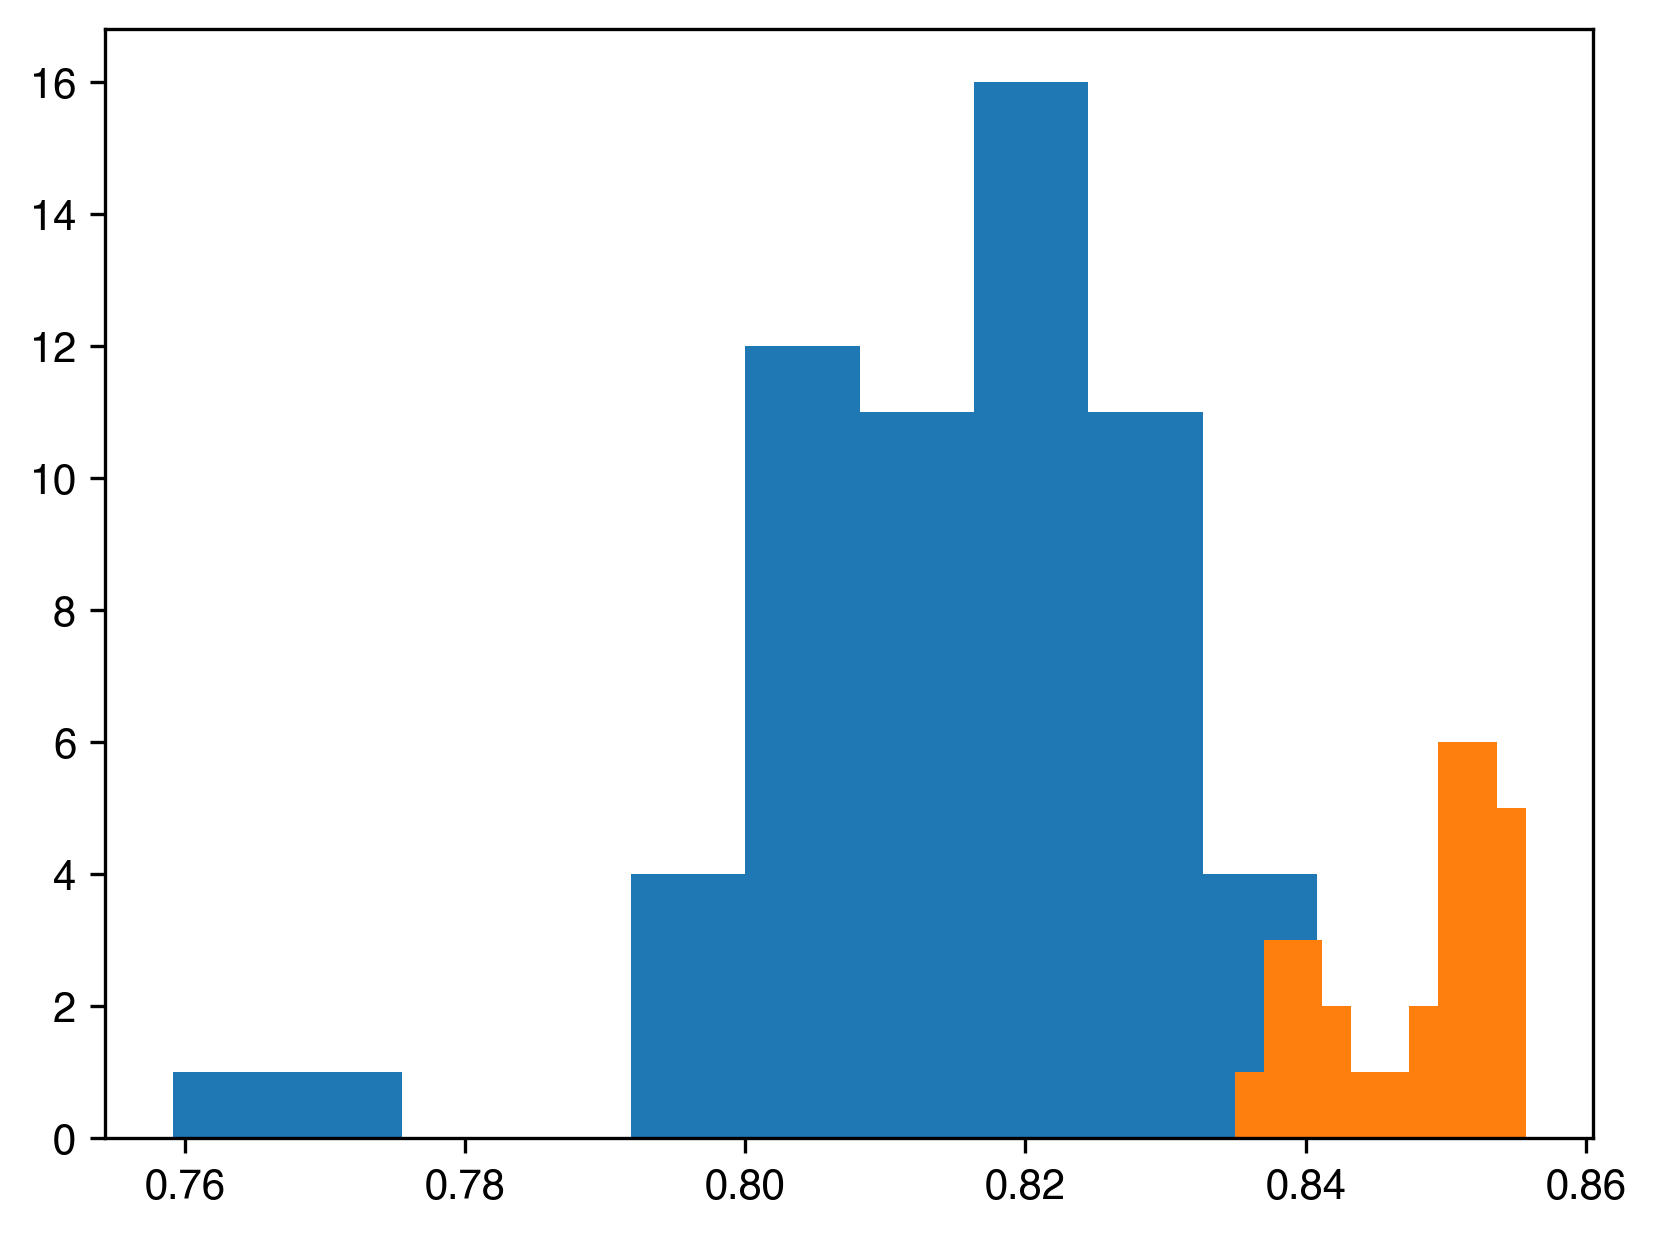

In [48]:
plt.hist(two_state_data_filtered[two_state_data_filtered['kernel_size'] == 40].sort_values("pearson_act_test", ascending=False)['pearson_act_test'])
plt.hist(simple_act_data[simple_act_data['kernel_size'] == 40].sort_values("pearson_act_test", ascending=False)['pearson_act_test'])

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


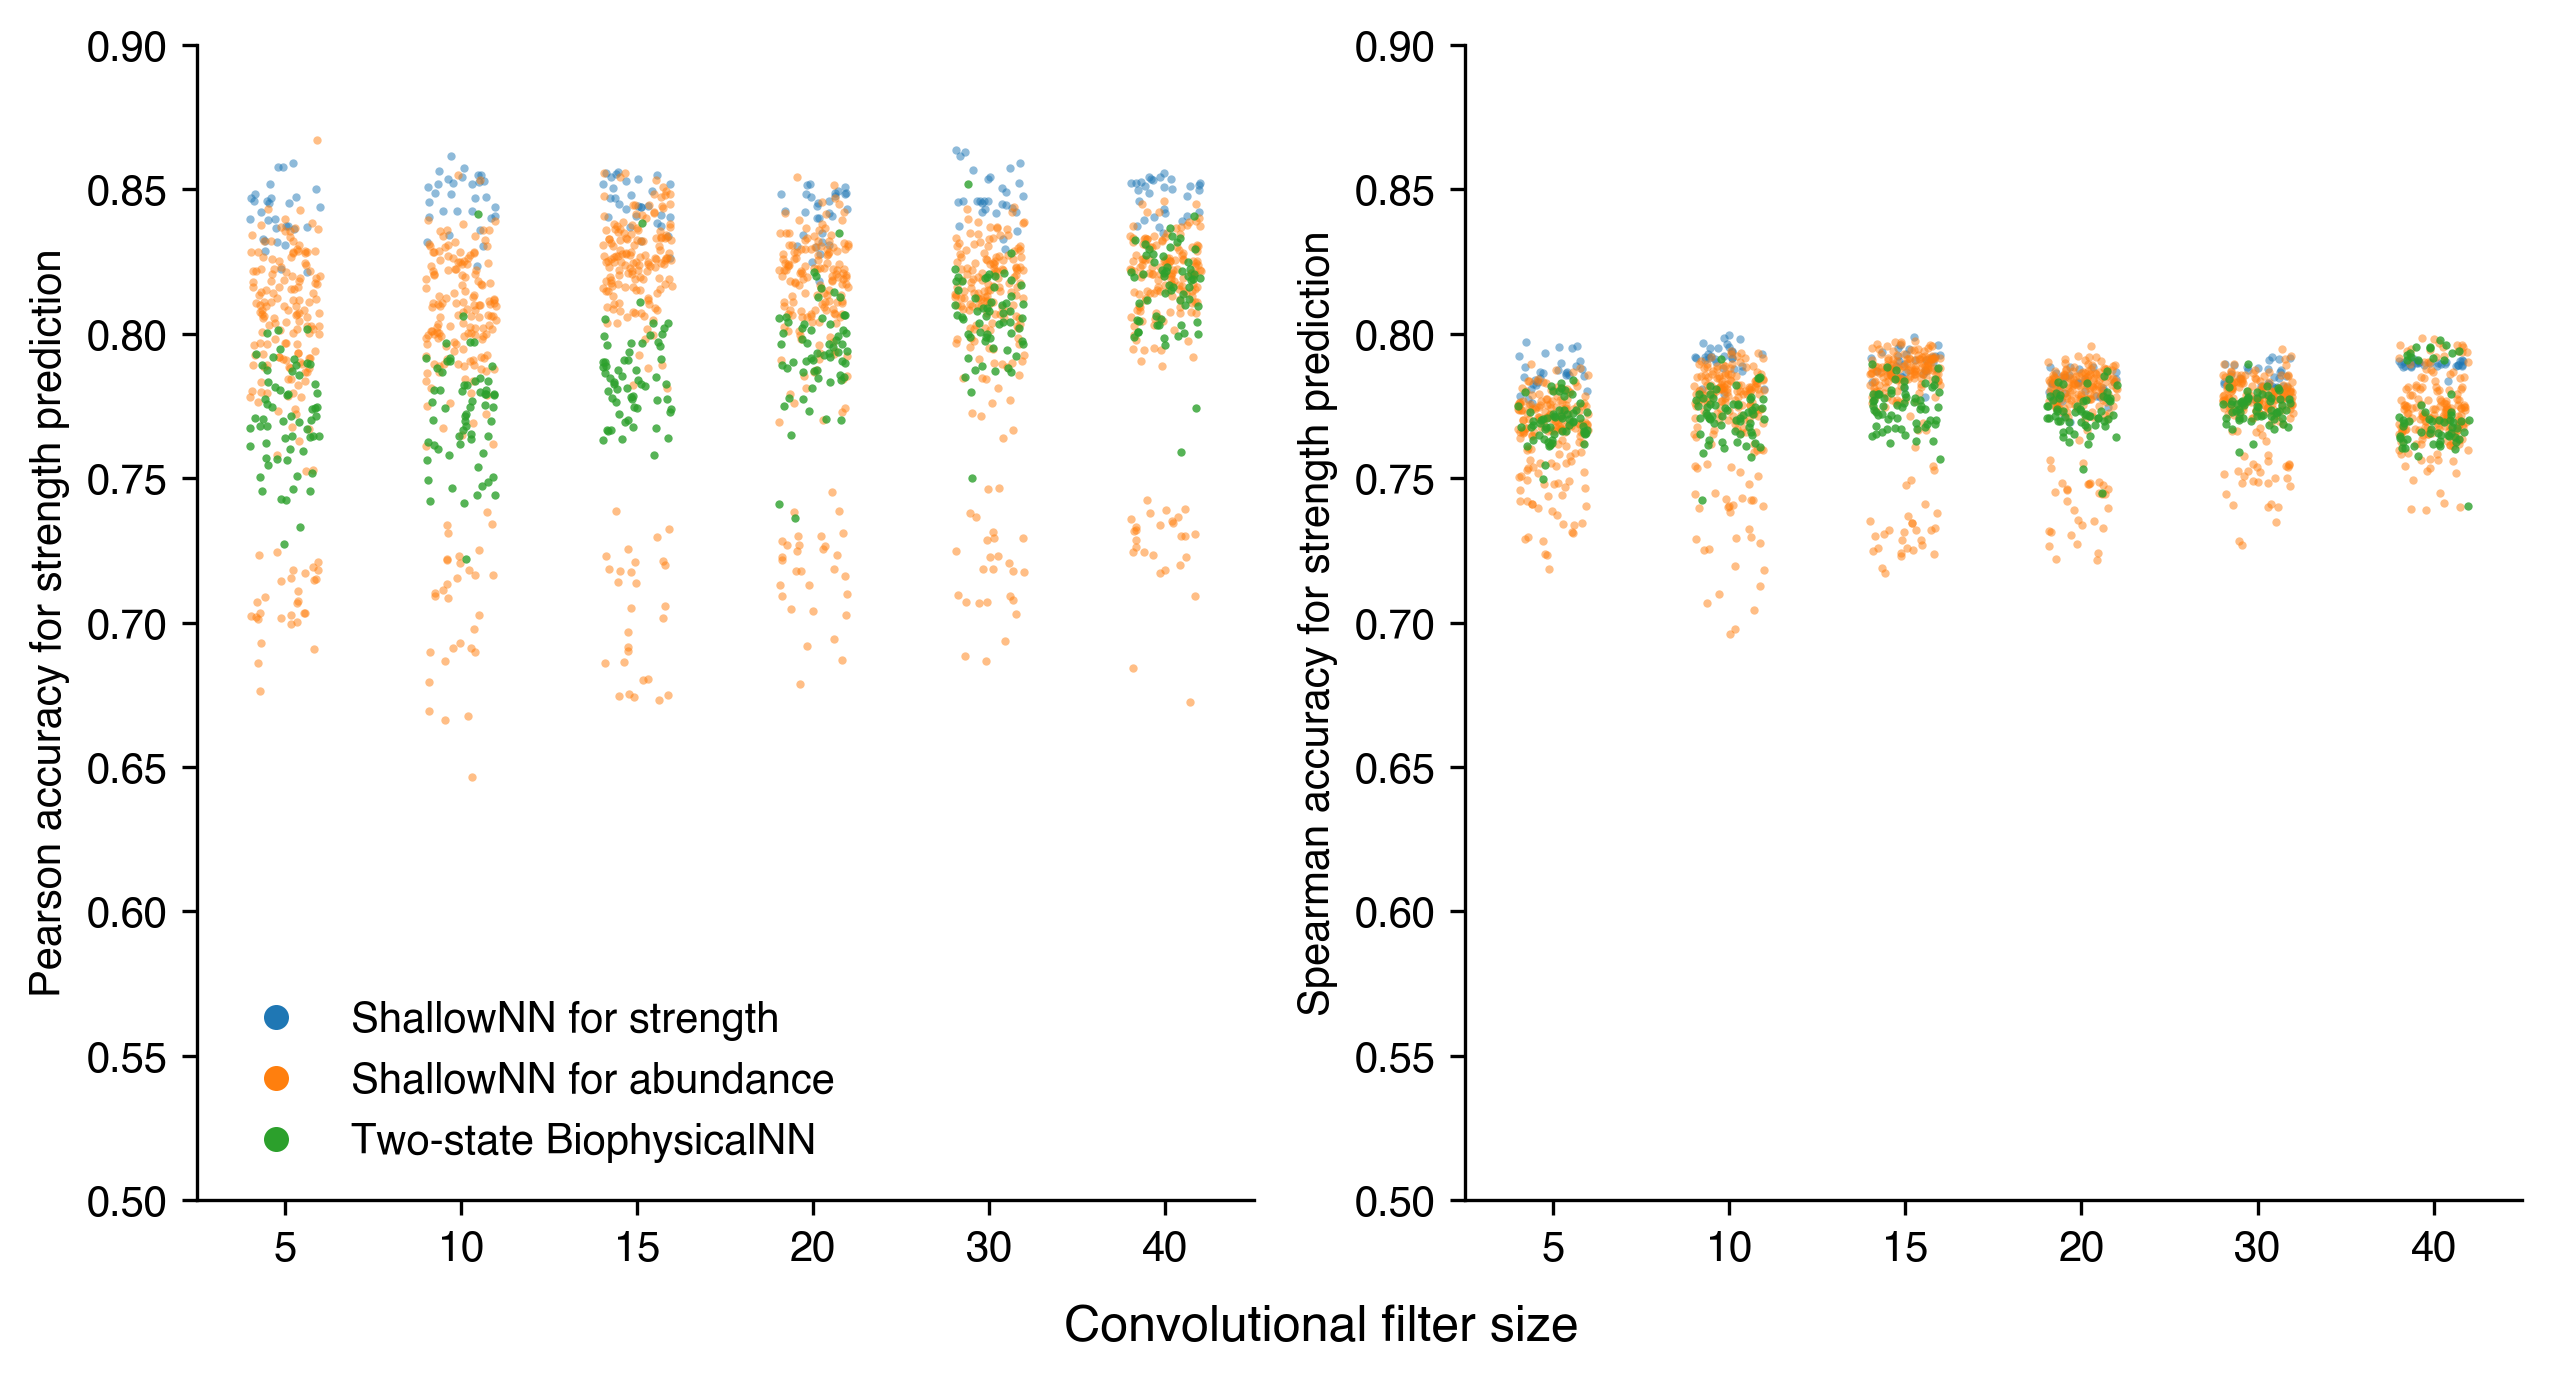

In [14]:
# Reading in the data from all the NN trainings

two_state_data_filtered = two_state_data[(two_state_data['activity_fun'] == "Hill") & (two_state_data['hill_value'] == 1)]
two_state_data_filtered = two_state_data_filtered[[k in [5, 10, 15, 20, 30, 40] for k in two_state_data_filtered['kernel_size']]]

fig, axs = plt.subplots(1,2, figsize = (10,5))

sns.stripplot(x="kernel_size", y="pearson_act_test", data=simple_act_data, jitter=0.2, size=2, alpha=0.5, ax=axs[0])
sns.stripplot(x="kernel_size", y="pearson_act_test", data=three_state_data, jitter=0.2, size=2, alpha=0.5, ax=axs[0])
sns.stripplot(x="kernel_size", y="pearson_act_test", data=two_state_data_filtered, jitter=0.2, alpha=0.8, size=2, ax=axs[0])

sns.stripplot(x="kernel_size", y="spearman_act_test", data=simple_act_data, jitter=0.2, size=2, alpha=0.5, ax=axs[1])
sns.stripplot(x="kernel_size", y="spearman_act_test", data=three_state_data, jitter=0.2, size=2, alpha=0.5, ax=axs[1])
sns.stripplot(x="kernel_size", y="spearman_act_test", data=two_state_data_filtered, jitter=0.2, alpha=0.8, size=2, ax=axs[1])


axs[1].set_xlabel("")
axs[0].set_xlabel("")
axs[0].set_ylabel("")
axs[1].set_ylabel("")

fig.supxlabel("Convolutional filter size")
axs[0].set_ylabel("Pearson accuracy for strength prediction")
axs[1].set_ylabel("Spearman accuracy for strength prediction")

# Getting legend
import matplotlib.lines as mlines

handles = [
    mlines.Line2D([], [], color='C0', marker='o', linestyle='None', markersize=5,
                  label='ShallowNN for strength'),
    mlines.Line2D([], [], color='C1', marker='o', linestyle='None', markersize=5,
                  label='ShallowNN for abundance'),
    mlines.Line2D([], [], color='C2', marker='o', linestyle='None', markersize=5,
                  label='Two-state BiophysicalNN')
]

axs[0].legend(handles=handles, frameon=False)



sns.despine()

axs[0].set_ylim(0.5, 0.9)
axs[1].set_ylim(0.5, 0.9)

plt.savefig("../../figures/for_revision/biophysical_seed_variation.pdf", format='pdf', bbox_inches='tight')
plt.savefig("../../figures/for_revision/biophysical_seed_variation.png", format='png', bbox_inches='tight')

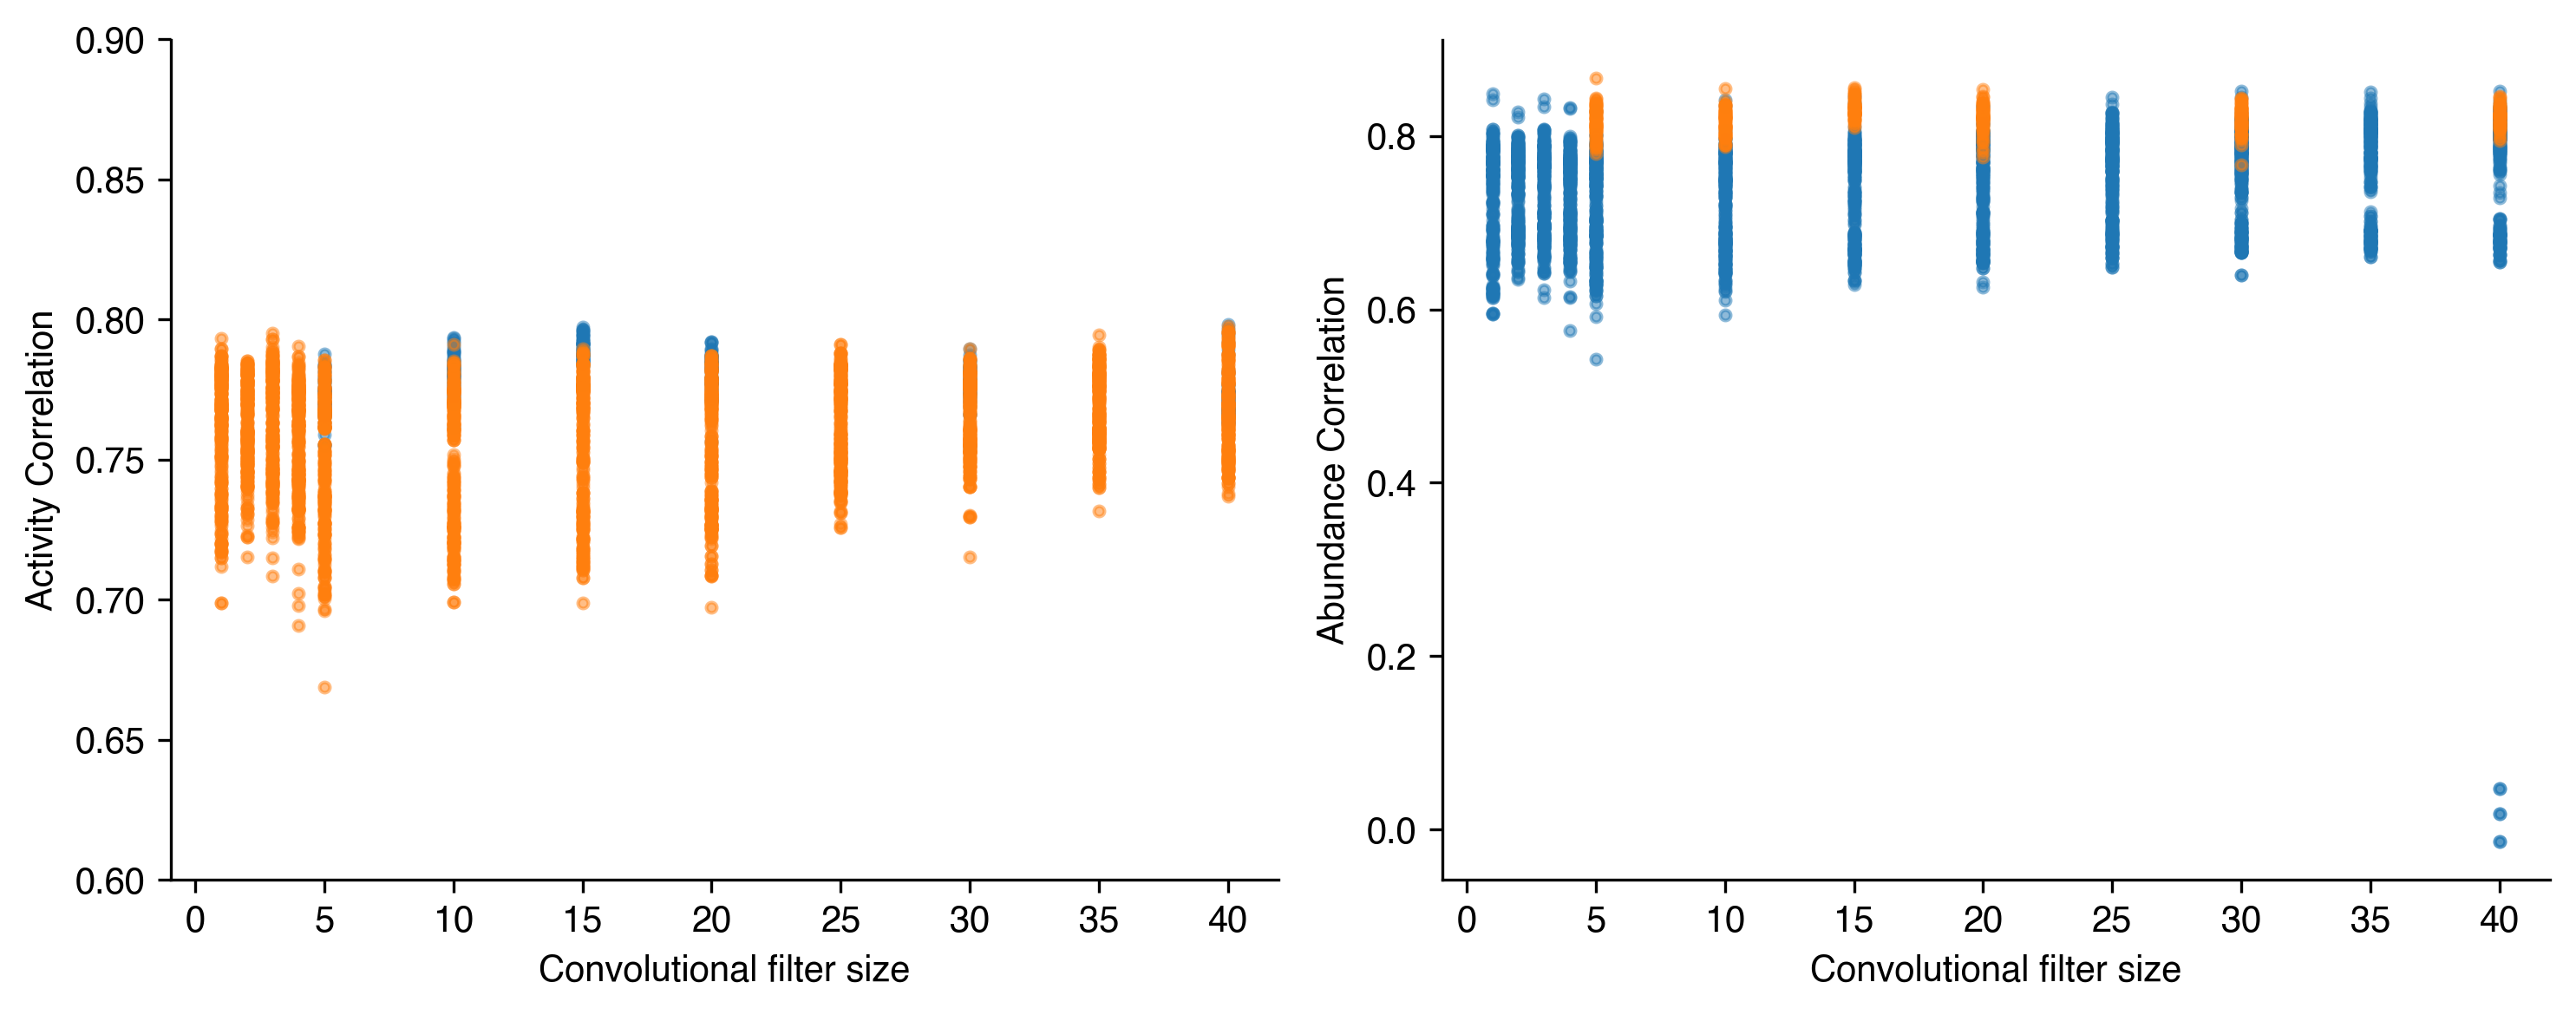

In [69]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].scatter(three_state_data['kernel_size'], three_state_data["spearman_act_test"], label="Spearman correlation", s=8, alpha=0.5)
axs[0].scatter(two_state_data['kernel_size'], two_state_data["spearman_act_test"], label="Spearman correlation", s=8, alpha=0.5)
axs[1].scatter(two_state_data['kernel_size'], two_state_data["pearson_act_test"], label="Pearson correlation", s=8, alpha=0.5)

axs[0].set_xlabel("Convolutional filter size")
axs[0].set_ylabel("Activity Correlation")

axs[1].scatter(three_state_data['kernel_size'], three_state_data["pearson_act_test"], label="Pearson correlation", s=8, alpha=0.5)

axs[1].set_xlabel("Convolutional filter size")
axs[1].set_ylabel("Abundance Correlation")

axs[0].set_ylim(0.6, 0.9)
sns.despine()
# axs[1].legend(frameon=False, bbox_to_anchor=(0.55,0.9))
fig.tight_layout()
# plt.savefig("../../figures/simple_seed_variation.pdf", format='pdf', bbox_inches='tight')
# plt.savefig("../../figures/simple_seed_variation.png", format='png', bbox_inches='tight')

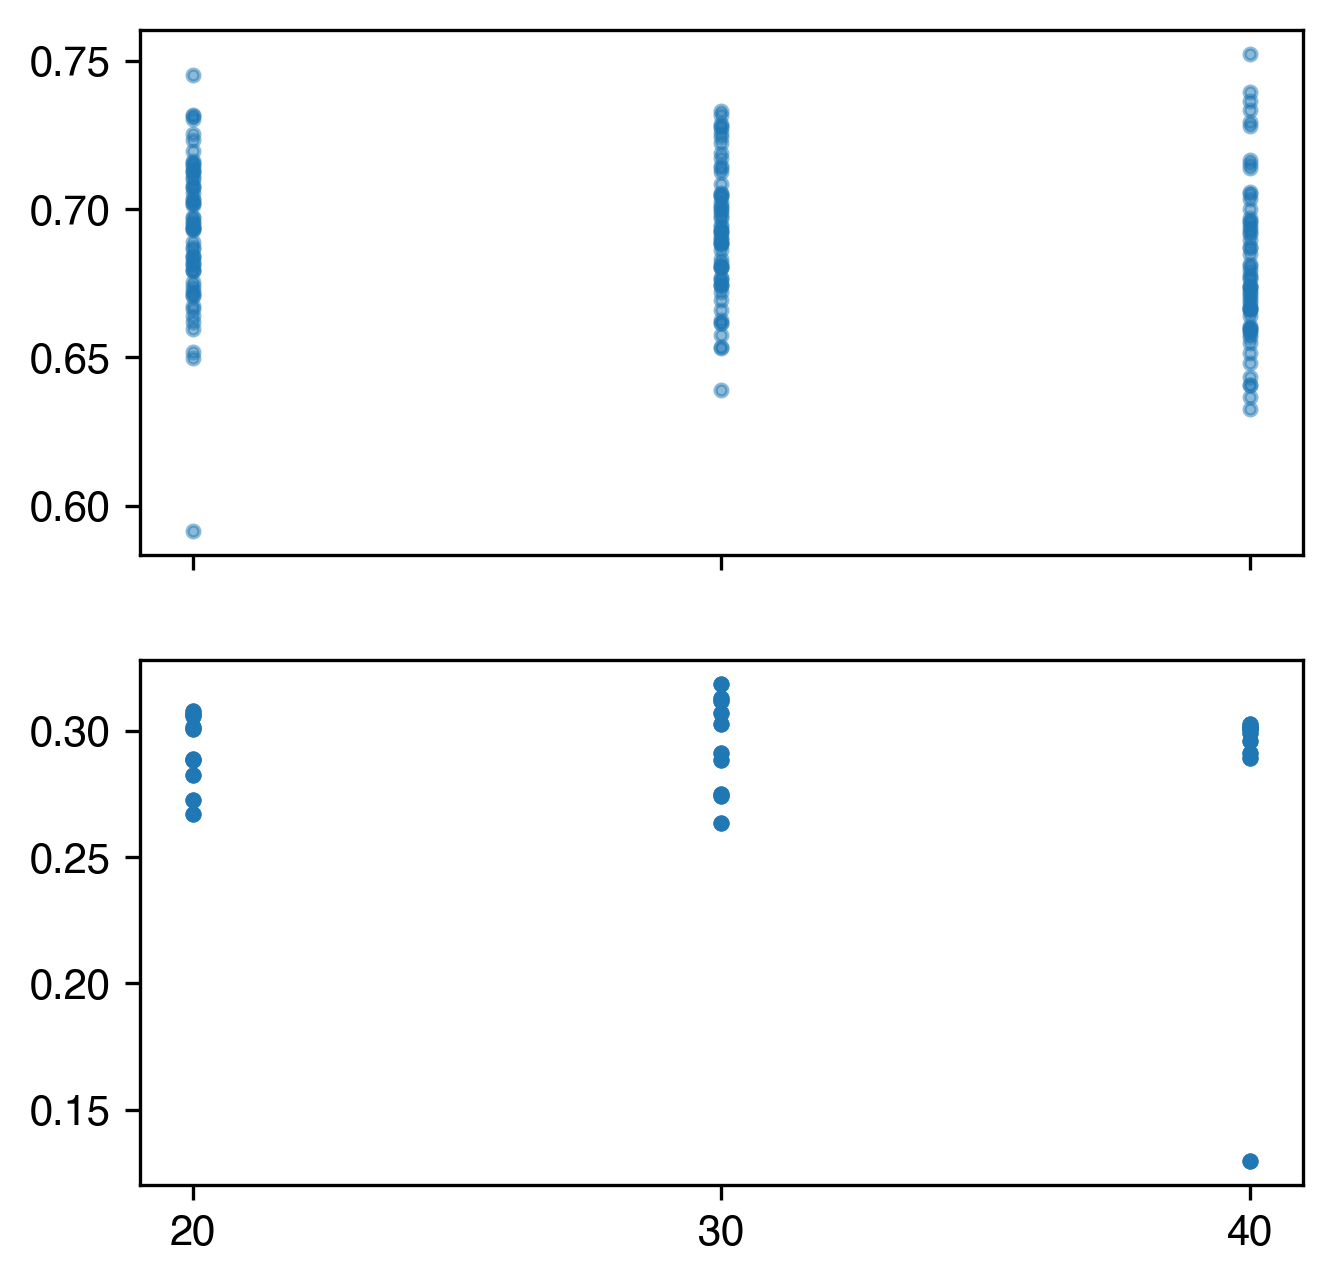

In [74]:
fig, axs = plt.subplots(2,1, sharex=True, figsize=(5,5))
axs[0].scatter(data_abund["abund_kernel_size"], data_abund["Rs1_act_val"], label="Three state NN", s=8, alpha=0.5)
axs[1].scatter(data_abund["abund_kernel_size"], data_abund[" Rsq_abund_val"], label="Three state NN", s=8, alpha=0.5)


In [ ]:
plt.scatter(data_abund[" Rsq_abund_val"], data_abund["Rs1_act_val"], label="Three state NN", s=8, alpha=0.5)


In [50]:
three_state_abund = data[data[" model_type"] == "three_state_abund"]
two_state_abund = data[data[" model_type"] == "two_state_abund"]
simple_act = data[data[" model_type"] == "simple_act"]
simple_abund = data[data[" model_type"] == "simple_abund"]

Text(0, 0.5, 'Pearson activity correlation')

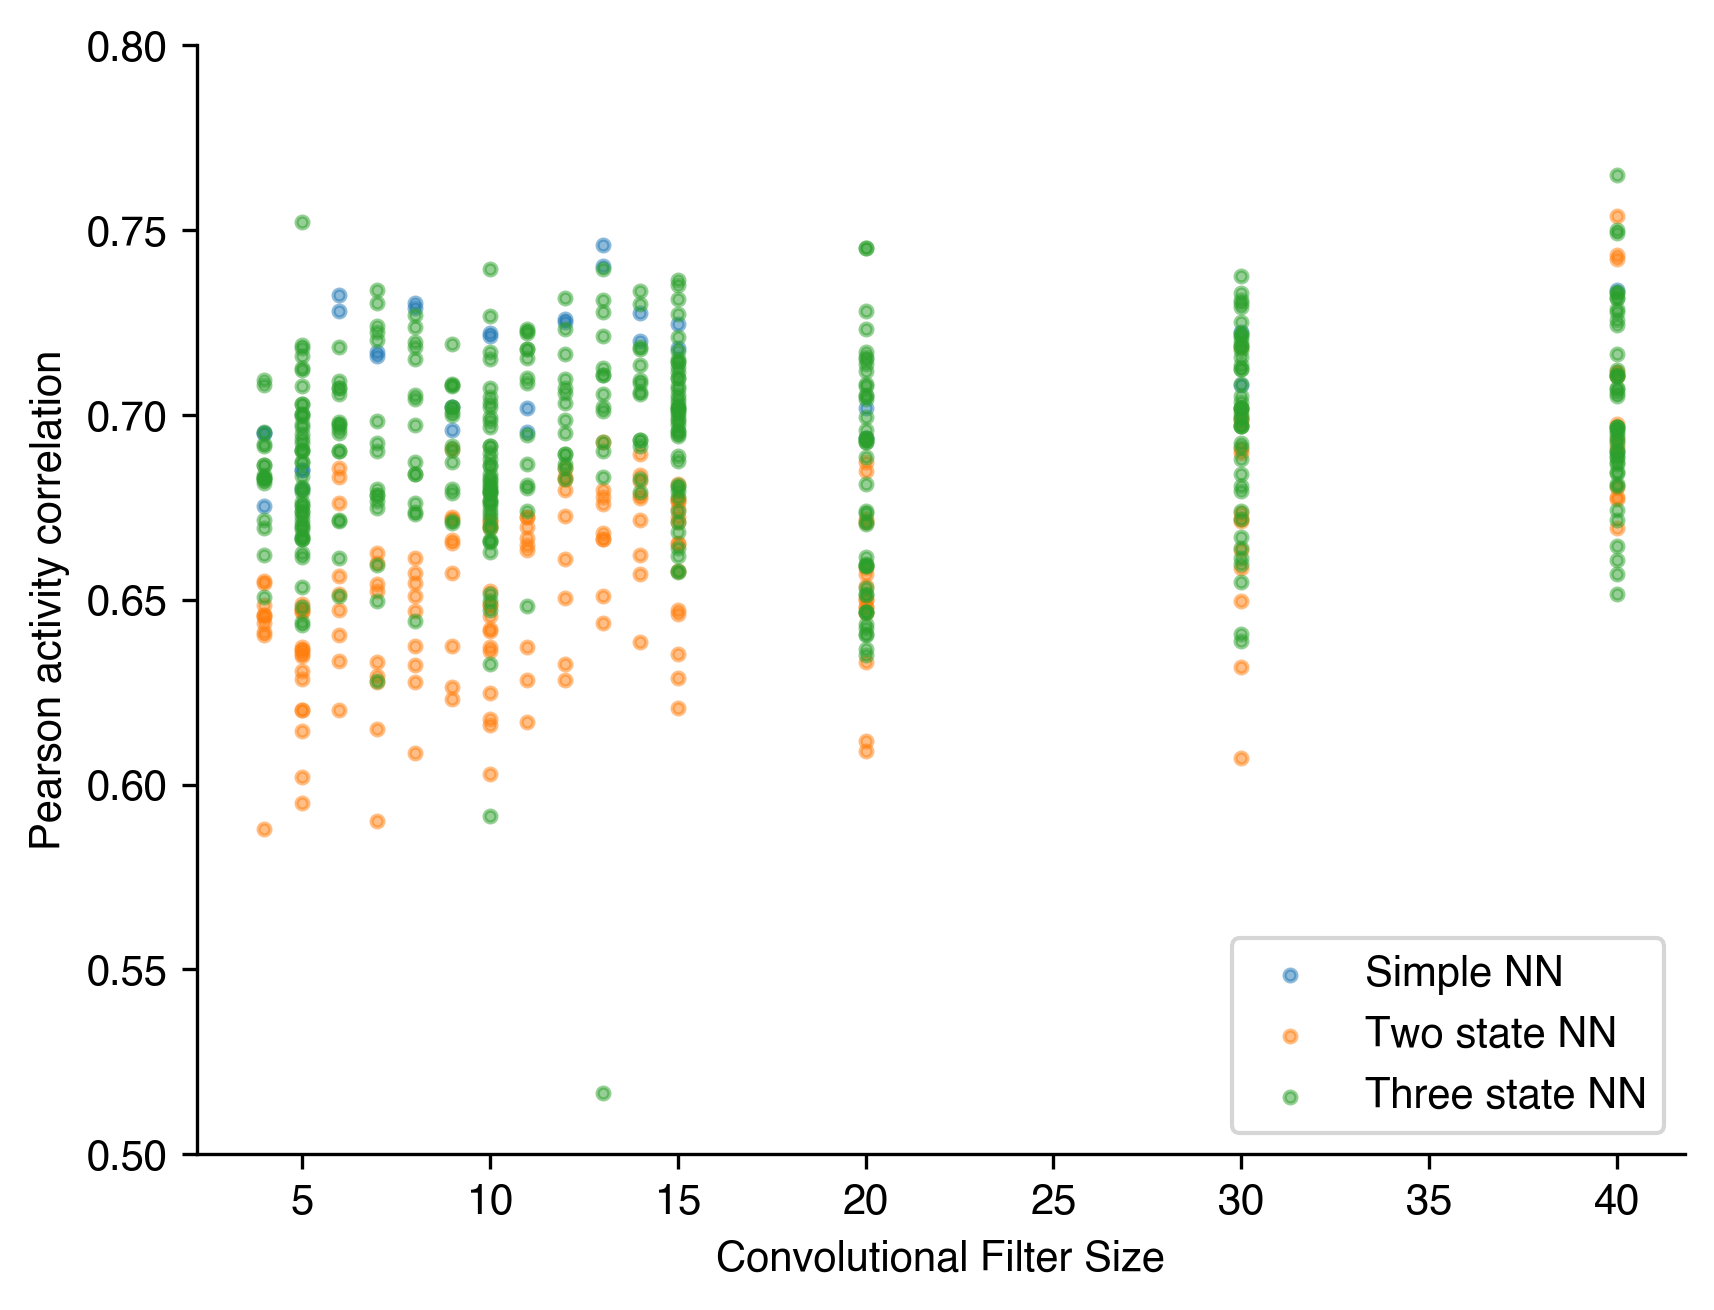

In [ ]:
plt.scatter(simple_act[" kernel_size"], simple_act["Rs1_act_val"], label="Simple NN", s=8, alpha=0.5)
plt.scatter(two_state_abund[" kernel_size"], two_state_abund["Rs1_act_val"], label="Two state NN", s=8, alpha=0.5)
plt.scatter(three_state_abund[" kernel_size"], three_state_abund["Rs1_act_val"], label="Three state NN", s=8, alpha=0.5)

plt.ylim(0.5, 0.8)
plt.legend()

axs = plt.gca()
axs.spines["top"].set_visible(False)
axs.spines["right"].set_visible(False)

# plt.xlabel("Convolutional Filter Size")
# plt.ylabel("Pearson activity correlation")

Text(0, 0.5, 'Pearson activity correlation')

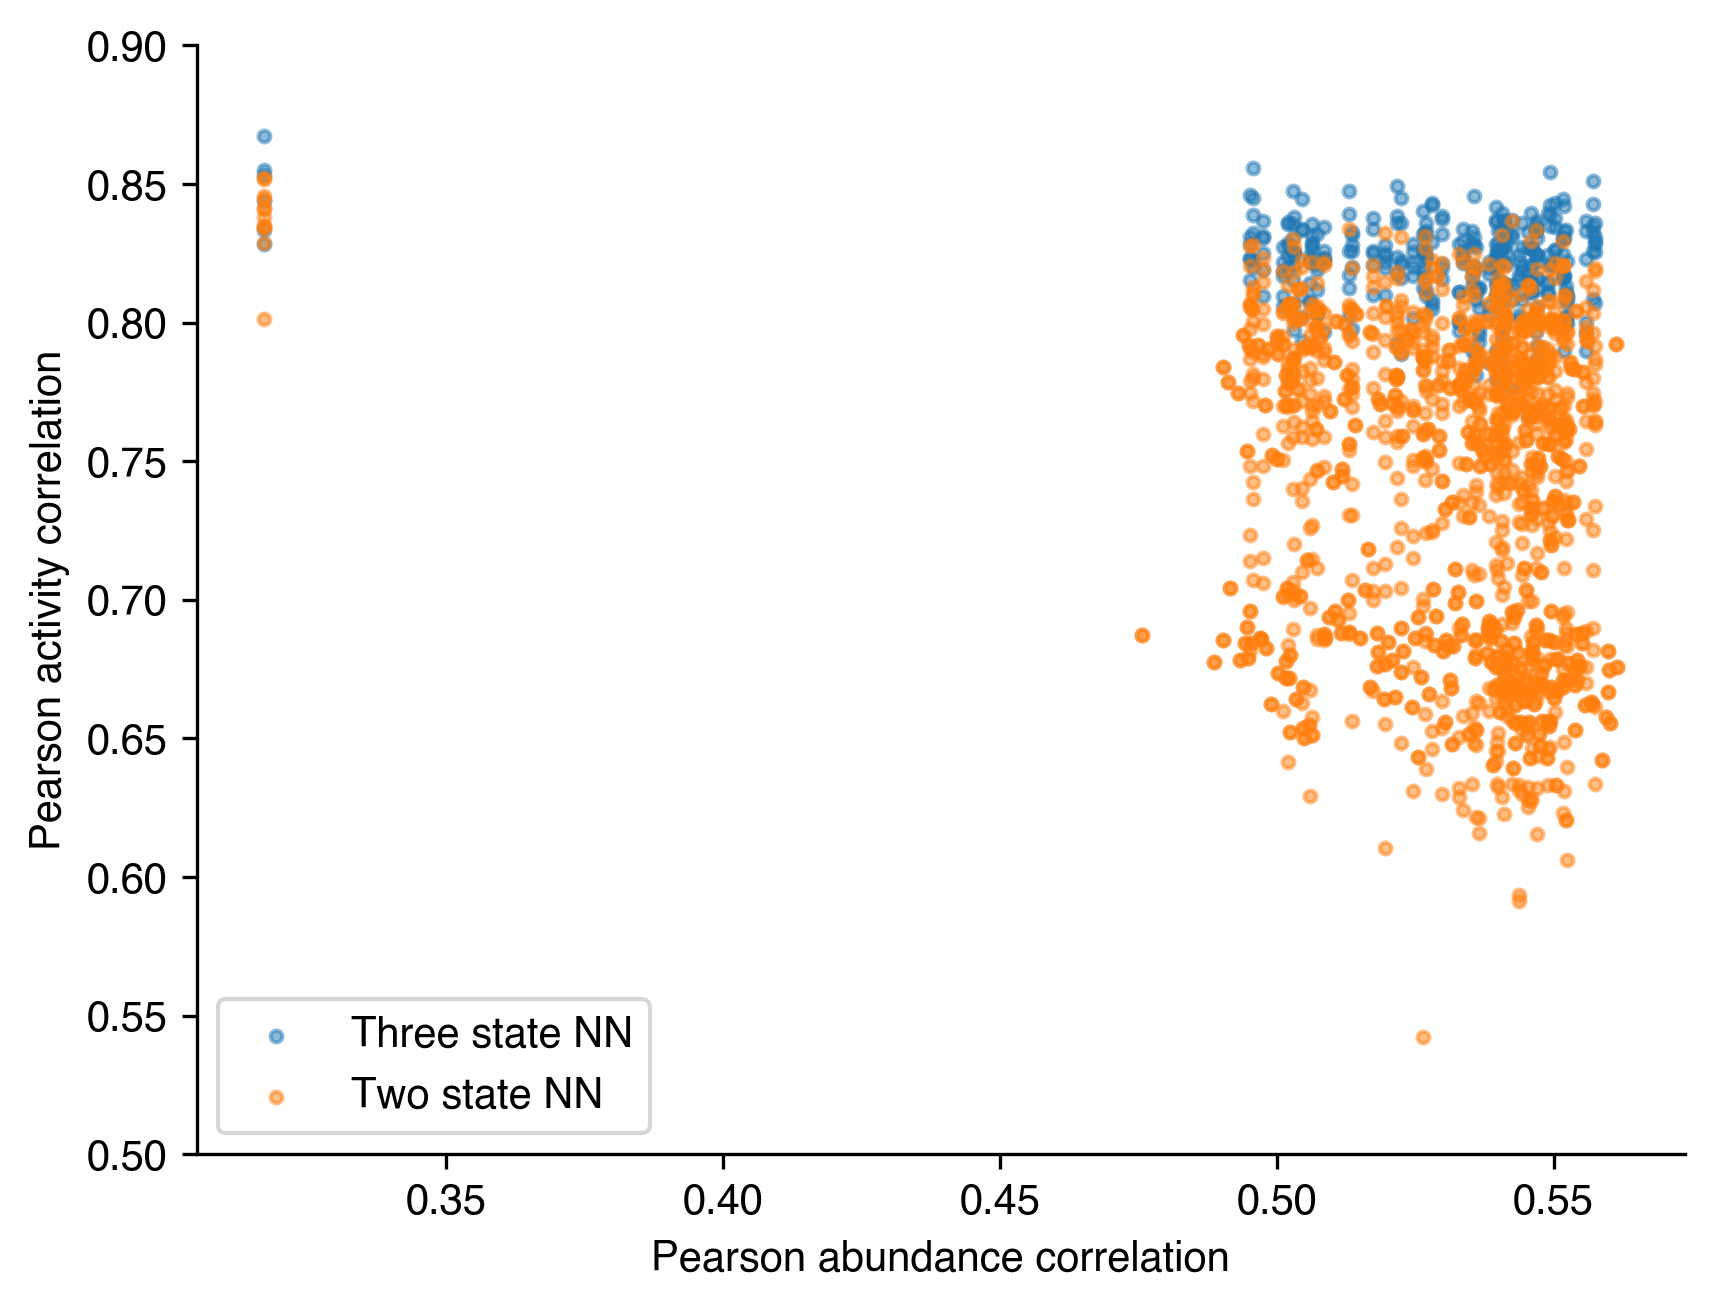

In [78]:
plt.scatter(three_state_data["pearson_abund_test"], three_state_data["pearson_act_test"], label="Three state NN", s=8, alpha=0.5)
plt.scatter(two_state_data_filtered["pearson_abund_test"], two_state_data_filtered["pearson_act_test"], label="Two state NN", s=8, alpha=0.5)

plt.ylim(0.5, 0.9)
plt.legend()

axs = plt.gca()
axs.spines["top"].set_visible(False)
axs.spines["right"].set_visible(False)

plt.xlabel("Pearson abundance correlation")
plt.ylabel("Pearson activity correlation")

In [97]:
stats.ttest_ind(two_state_data_filtered[two_state_data_filtered['activity_fun'] == "Hill"]["spearman_act_test"], two_state_data_filtered[two_state_data_filtered['activity_fun'] == "Linear"]["spearman_act_test"], equal_var=False)

TtestResult(statistic=3.8625248085154773, pvalue=0.00012091789824801005, df=833.6362932351435)

In [98]:
np.mean(two_state_data_filtered[two_state_data_filtered['activity_fun'] == "Hill"]["spearman_act_test"])

0.7586210414017337

In [99]:
np.mean(two_state_data_filtered[two_state_data_filtered['activity_fun'] == "Linear"]["spearman_act_test"])

0.7479796999092245

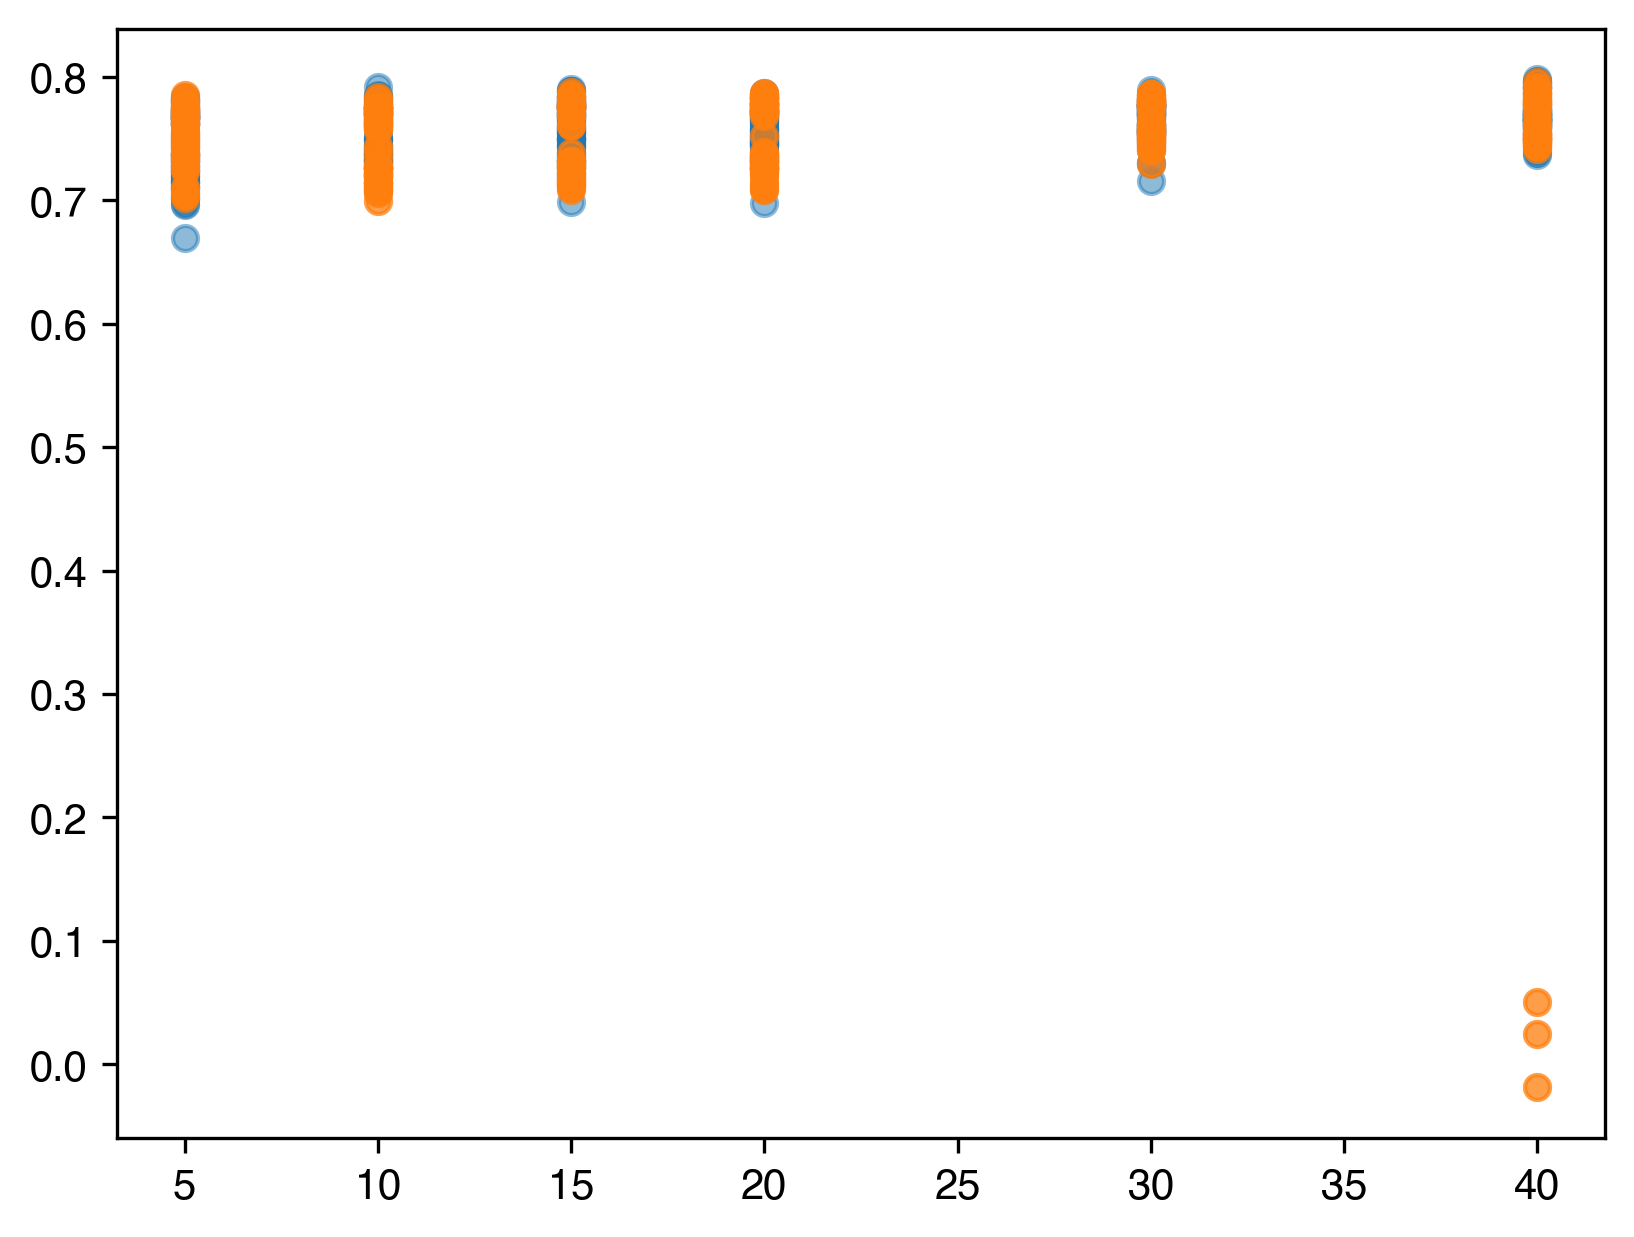

In [96]:
# plt.scatter(two_state_data_filtered[two_state_data_filtered['activity_fun'] == "Hill"]["kernel_size"], two_state_data_filtered[two_state_data_filtered['activity_fun'] == "Hill"]["pearson_act_test"], alpha=0.5)
# plt.scatter(two_state_data_filtered[two_state_data_filtered['activity_fun'] == "Linear"]["kernel_size"], two_state_data_filtered[two_state_data_filtered['activity_fun'] == "Linear"]["pearson_act_test"], alpha=0.5)

plt.scatter(two_state_data_filtered[two_state_data_filtered['activity_fun'] == "Hill"]["kernel_size"], two_state_data_filtered[two_state_data_filtered['activity_fun'] == "Hill"]["spearman_act_test"], alpha=0.5)
plt.scatter(two_state_data_filtered[two_state_data_filtered['activity_fun'] == "Linear"]["kernel_size"], two_state_data_filtered[two_state_data_filtered['activity_fun'] == "Linear"]["spearman_act_test"], alpha=0.5)

# plt.ylim(0.5, 0.9)
# plt.legend()

# axs = plt.gca()
# axs.spines["top"].set_visible(False)
# axs.spines["right"].set_visible(False)

# plt.xlabel("Pearson abundance correlation")
# plt.ylabel("Pearson activity correlation")

Text(0, 0.5, 'Pearson activity correlation')

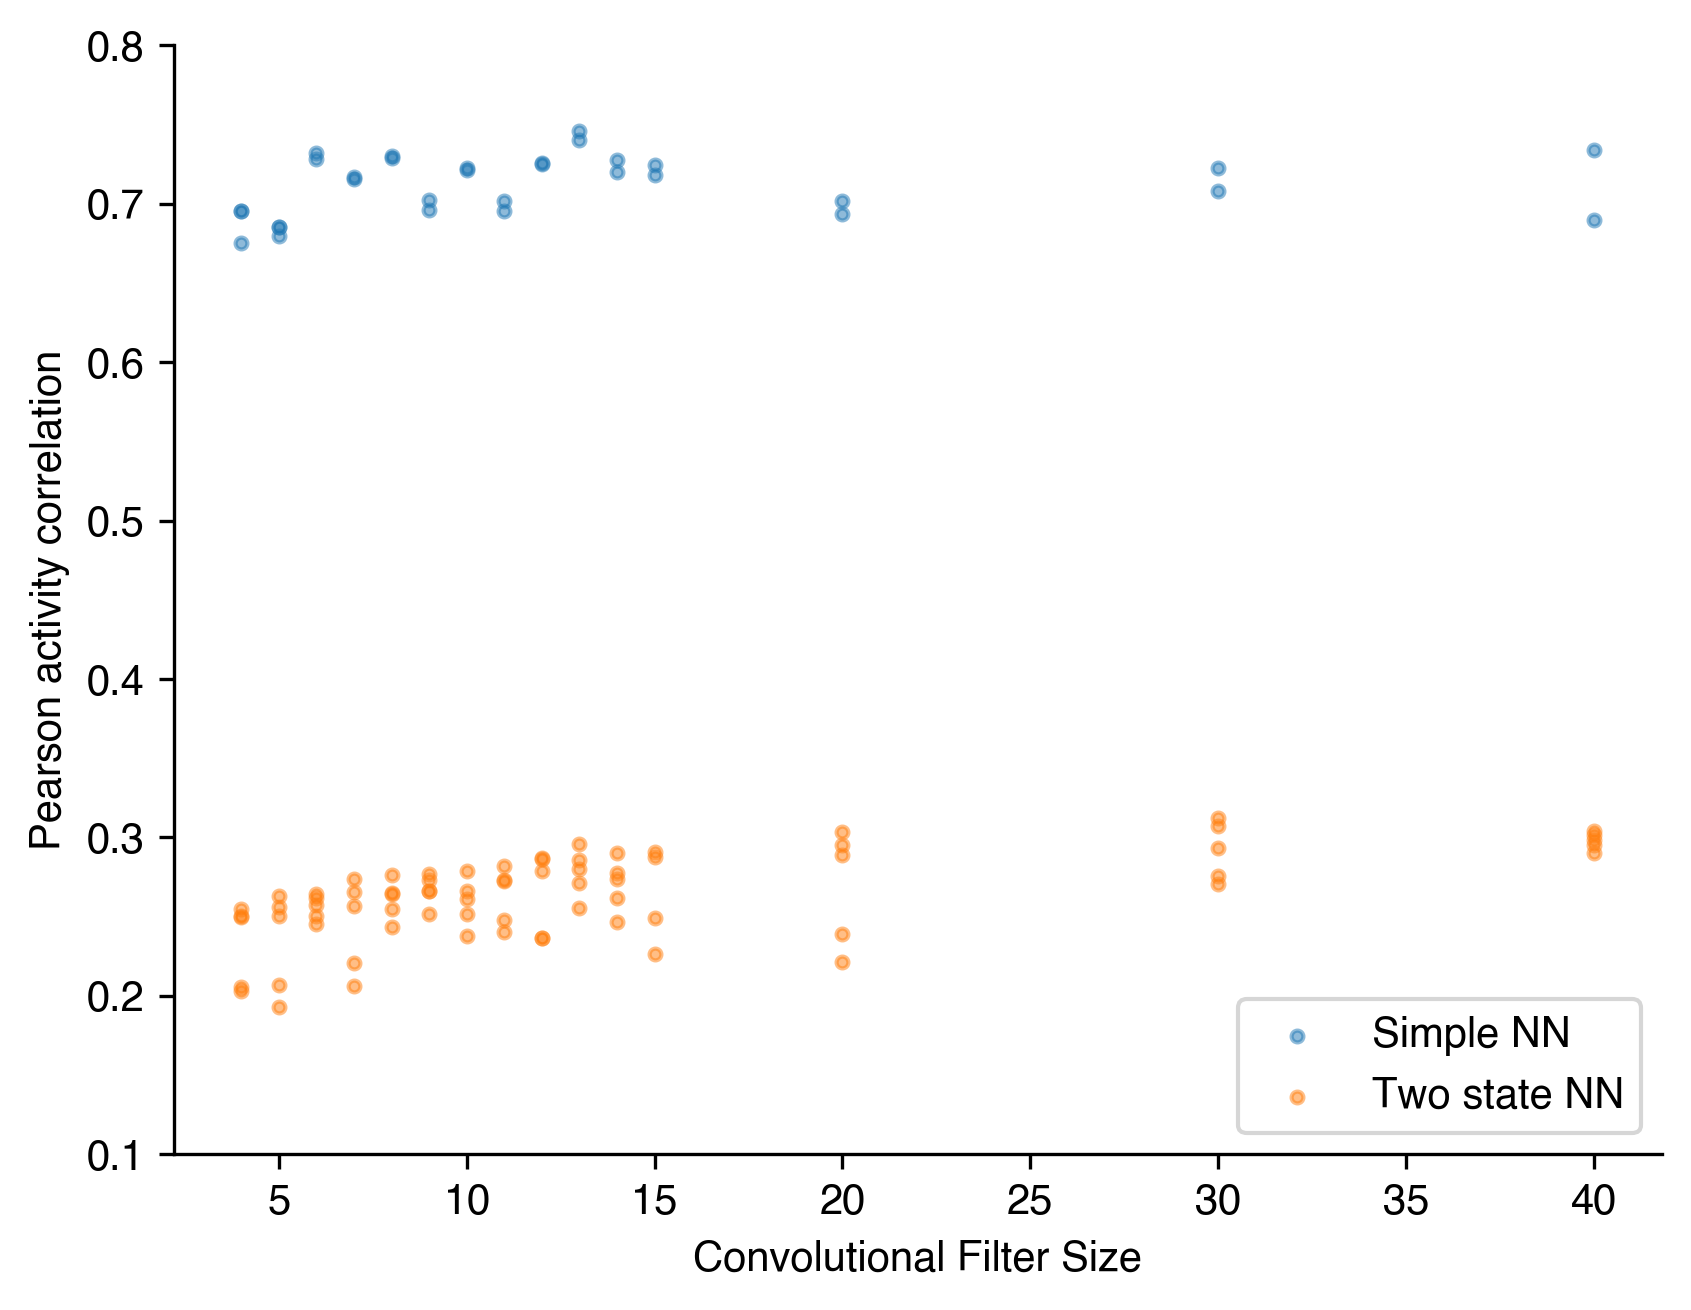

In [47]:
plt.scatter(simple_act[" kernel_size"], simple_act["Rs1_act_val"], label="Simple NN", s=8, alpha=0.5)
plt.scatter(simple_abund[" kernel_size"], simple_abund[" Rsq_abund_val"], label="Two state NN", s=8, alpha=0.5)

plt.ylim(0.1, 0.8)
plt.legend()

axs = plt.gca()
axs.spines["top"].set_visible(False)
axs.spines["right"].set_visible(False)

plt.xlabel("Convolutional Filter Size")
plt.ylabel("Pearson activity correlation")